# Rainfall data inventory
HEALpix continues to be my ops.

| Model | Zooms | DWTP | Global monsoon | Monthly bias |
|-------|-------|------|----------------|--------------|
| [`um_glm_n2560_RAL3p3_tuned_hk26`](#UM)  | all | fine | not started |
| [`um_glm_n2560_CoMA9_hk26`](#UM) | all | fine | not started |
| [`um_glm_n1280_CoMA9_hk26`](#UM)   | all | fine | not started |
| [`um_glm_n1280_GAL9_v2_hk26`](#UM)   | all | fine | not started |
| [`nicam_gl11`](#NICAM)  | all | fine(?) | not started |
| [`ifs_tco3999-ng5_rcbmf_cf`](#IFS)* | 7,11 | weird spike at start but fine now | not started |
| [`icon_d3hp003`](#ICON) | all | fine | not started |
| [`casesm2_10km_nocumulus`](#CASESM) | all | 8+ problems with times but 7 fine | not started |
| [`arp-gem-2p6km1`](#ARP-GEM) | 8 only | running | not started |
| [`IR_IMERG`](#IMERG) | 9 only | running | not started |

*note this is the coupled IFS so really not an ideal comparison but all the non-cf IFS outputs are PAINFUL to read.

## Neglected models
| Model | Reason |
|-------|--------|
| [`scream-dkrz`](#SCREAM) | It started in 2019 and uses a calendar without a leap year. |
| [`icon-ngc4008`](#ICON-nextgems) | There's a message on the mattermost saying not to use this. |

In [3]:
import os
import sys
import datetime as dt
import cmocean as cmo

import cartopy.crs as ccrs
import easygems.healpix as egh
import intake
import matplotlib.pyplot as plt
import numpy as np

import healpy as hp
import xarray as xr

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
# Filter out annoying warning.
import warnings

from utils import haversine, hp_mods, get_nn_lon_lat_index, hp_to_latlon

warnings.filterwarnings(
    "ignore",
    message=".*The return type of `Dataset.dims` will be changed.*",
    category=FutureWarning,
)

In [4]:
# Open catalog.
url = 'https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml'
cat = intake.open_catalog(url)['UK']
[sim for sim in cat]

['CERES_EBAF',
 'ERA5',
 'IR_IMERG',
 'JRA3Q',
 'MERRA2',
 'arp-gem-1p3km',
 'arp-gem-2p6km',
 'casesm2_10km_nocumulus',
 'icon_d3hp003',
 'icon_d3hp003aug',
 'icon_d3hp003feb',
 'icon_ngc4008',
 'ifs_tco3999-ng5_deepoff',
 'ifs_tco3999-ng5_rcbmf',
 'ifs_tco3999-ng5_rcbmf_cf',
 'ifs_tco3999_rcbmf',
 'nicam_220m_test',
 'nicam_gl11',
 'scream-dkrz',
 'tracking-d3hp003',
 'um_Africa_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26',
 'um_Africa_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_Africa_km4p4_RAL3P3_n2560_CoMA9_nest_hk26',
 'um_CTC_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26',
 'um_CTC_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_CTC_km4p4_RAL3P3_n2560_CoMA9_nest_hk26',
 'um_SAmer_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26',
 'um_SAmer_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_SAmer_km4p4_RAL3P3_n2560_CoMA9_nest_hk26',
 'um_SEA_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26',
 'um_SEA_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_SEA_km4p4_RAL3P3_n2560_CoMA9_nest_hk26',
 'um_glm_n1280_CoMA9_TBv1p2',
 'um_glm_n1280_CoMA9_hk26',

In [3]:
viable_sims = [
    "IR_IMERG",
    "arp-gem-2p6km",
    "casesm2_10km_nocumulus",
    "icon_d3hp003",
    "ifs_tco3999-ng5_rcbmf_cf",
    "nicam_gl11",
    "scream-dkrz",
    "um_glm_n1280_CoMA9_hk26",
    "um_glm_n1280_GAL9_v2_hk26",
    "um_glm_n2560_CoMA9_hk26",
    "um_glm_n2560_RAL3p3_tuned_hk26",
]


## UM
come on engerland. UK represent this is the only functional model really

In [8]:
zoom = 4
ds = (
    cat["um_glm_n2560_RAL3p3_tuned_hk26"](zoom=zoom, time="PT1H")
    .to_dask()
    .pipe(hp_mods)
    .pr
    .sel(time=slice("2020-03-01","2021-02-28"))
)
ds_latlon = hp_to_latlon(ds, zoom)
print(f"original units: {ds_latlon.units}")
ds_latlon *= 3600
ds_latlon["units"] = "mm h-1"

In [9]:
ds_latlon.resample(time="1ME").mean().plot(col="time", col_wrap=4, cmap="Blues")

## NICAM

In [17]:
zoom = 4
ds = (
    cat["nicam_gl11"](zoom=zoom)
    .to_dask()
    .pipe(egh.attach_coords)
    .pr
    .sel(time=slice("2020-03-01","2021-02-28"))
    
)

ds_latlon = hp_to_latlon(ds, zoom)
print(f"original units: {ds_latlon.units}")
ds_latlon *= 3600
ds_latlon["units"] = "mm h-1"

In [18]:
ds_latlon.resample(time="1ME").mean().plot(
    col="time",
    col_wrap=4,
    cmap="Blues",
    vmin=0,
    vmax=1.5,
)

## IFS

It's very important to select sensible times for this one because if you don't. There's an insane spike at the beginning.

<xarray.DataArray 'time' (time: 10201)> Size: 82kB
array(['2020-01-01T00:00:00.000000000', '2020-01-01T00:59:44.000000000',
       '2020-01-01T01:59:28.000000000', ..., '2021-02-28T22:00:32.000000000',
       '2021-02-28T23:00:16.000000000', '2021-03-01T00:00:00.000000000'],
      shape=(10201,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 82kB 2020-01-01 ... 2021-03-01
    crs      int64 8B 0

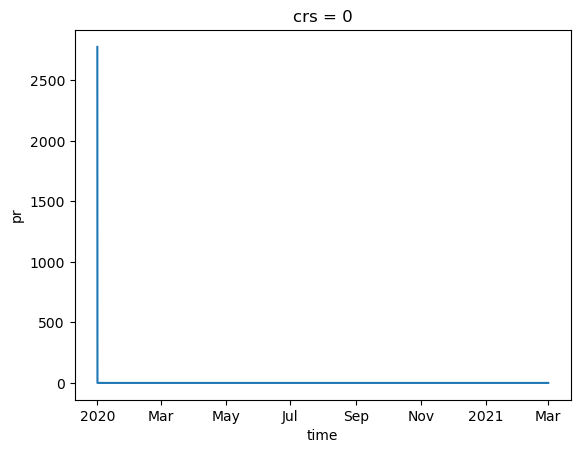

In [6]:
zoom = 7
ds = (
    cat["ifs_tco3999-ng5_rcbmf_cf"](zoom=zoom, time="PT1H")
    .to_dask()
    .pipe(egh.attach_coords)
    .pr
)
ds.mean(dim="cell").plot()
ds.time

In [19]:
zoom = 7
ds = (
    cat["ifs_tco3999-ng5_rcbmf_cf"](zoom=zoom, time="PT1H")
    .to_dask()
    .pipe(egh.attach_coords)
    .pr
    .sel(time=slice("2020-03-01","2021-02-28"))
)
ds_latlon = hp_to_latlon(ds, zoom)
print(f"original units: {ds_latlon.units}")
ds_latlon *= 3600
ds_latlon["units"] = "mm h-1"

In [20]:
ds_latlon.resample(time="1ME").mean().plot(
    col="time",
    col_wrap=4,
    cmap="Blues",
    vmin=0,
    vmax=1.5,
)

## ICON
ok my second favourite I will confess. eminently usable. 

In [31]:
zoom = 7
ds = (
    cat["icon_d3hp003"](zoom=zoom)
    .to_dask()
    .pipe(egh.attach_coords)
    .pr
    .sel(time=slice("2020-03-01","2021-02-28"))
)
ds_latlon = hp_to_latlon(ds, zoom)
print(f"original units: {ds_latlon.units}")
ds_latlon *= 3600
ds_latlon["units"] = "mm h-1"

In [32]:
ds_latlon.resample(time="1ME").mean().plot(
    col="time",
    col_wrap=4,
    cmap="Blues",
    vmin=0,
    vmax=1.5,
)

## CASESM
Some weird stuff is happening with times in the higher zooms.

Also just takes waaayyy longer and invariably crashes the server. Why? I fear the load is not lazying.

In [15]:
zoom = 3
ds = (
    cat["casesm2_10km_nocumulus"](zoom=zoom,time="PT1H")
    .to_dask()
    .pipe(egh.attach_coords)
    .pr
    .sel(time=slice("2020-03-01","2021-02-28"))
)
ds_latlon = hp_to_latlon(ds, zoom)
print(f"doesn't HAVE units originally shgjhaslfgjk")
ds_latlon *= 3600
ds_latlon["units"] = "mm h-1"


doesn't HAVE units originally shgjhaslfgjk


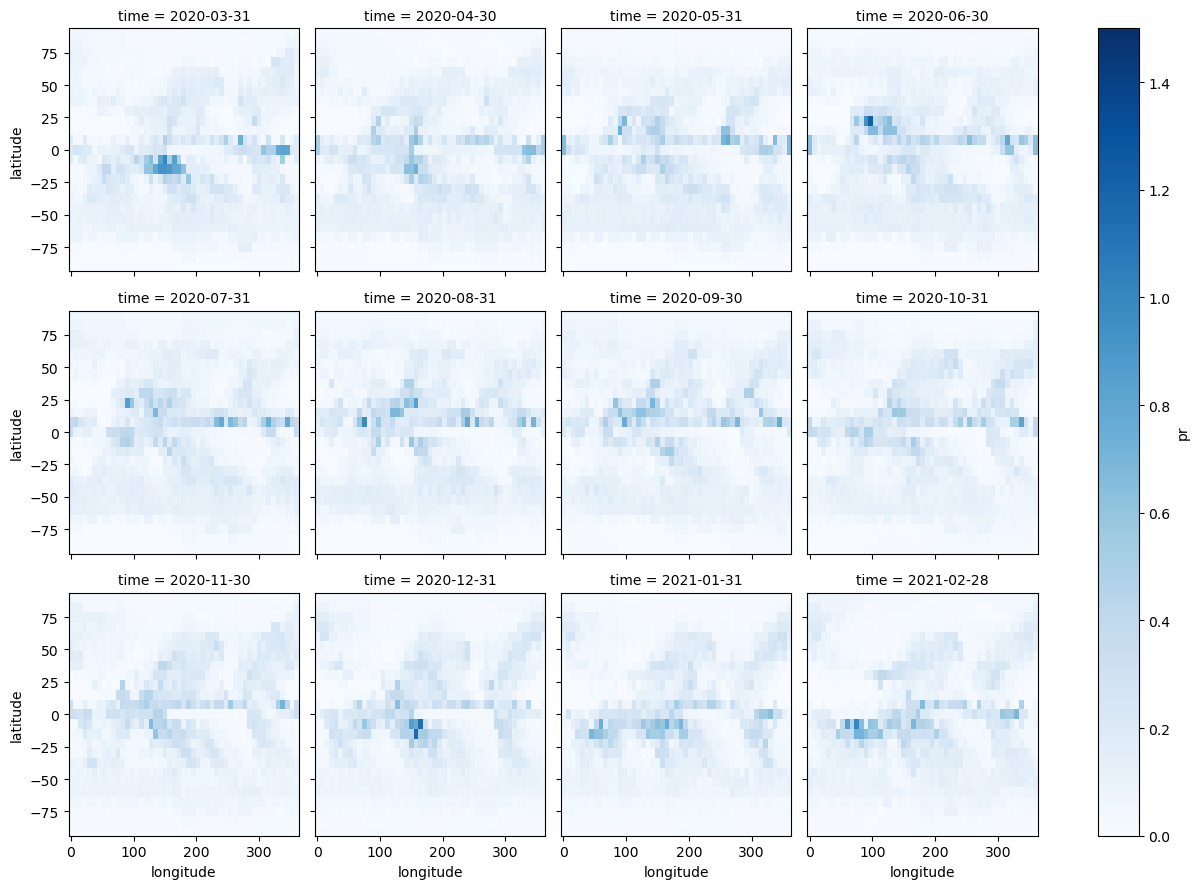

In [16]:
ds_latlon.resample(time="1ME").mean().plot(
    col="time",
    col_wrap=4,
    cmap="Blues",
    vmin=0,
    vmax=1.5,
)

## SCREAM
my ops,

hahahaha oh my god it starts in August 2019 what are you DOING

In [24]:
zoom = 3
ds = (
    cat["scream-dkrz"](zoom=zoom,time="PT1H")
    .to_dask()
    .pipe(egh.attach_coords)
    .pr
    # .sel(time=slice("2020-03-01","2021-02-28"))
)
ds_latlon = hp_to_latlon(ds, zoom)
print(f"original units: {ds_latlon.units}")
ds_latlon *= 3600 * 1000
ds_latlon["units"] = "mm h-1"
# ds.mean(dim="cell").plot()

original units: m s^-1


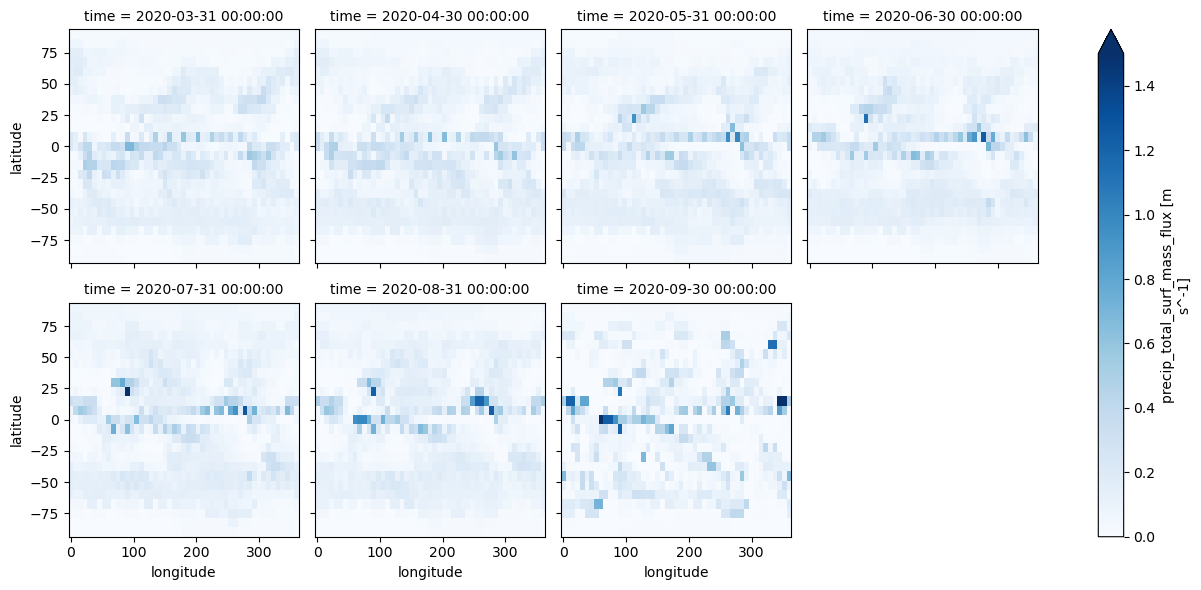

In [20]:
ds_latlon.resample(time="1ME").mean().plot(
    col="time",
    col_wrap=4,
    cmap="Blues",
    vmin=0,
    vmax=1.5,
)

# ARP-GEM
Only available on zoom 8 which seems too tricky to open in a notebook. Theoretically should be functional though; has sensible times and everything

In [8]:
zoom = 8
ds = (
    cat["arp-gem-2p6km"](zoom=zoom,time="PT1H")
    .to_dask()
    # .pipe(egh.attach_coords)
    .pr
    .sel(time=slice("2020-03-01","2020-03-02"))
)
ds_latlon = hp_to_latlon(ds, zoom)
print(f"original units: {ds.units}")
ds_latlon *= 3600
ds_latlon["units"] = "mm h-1"


original units: kg m-2 s-1


In [10]:
dsds = cat["arp-gem-2p6km"](zoom=zoom,time="PT1H").to_dask().pr
dsds

<xarray.DataArray 'pr' (time: 10200, cell: 786432)> Size: 32GB
[8021606400 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 82kB 2020-01-01T01:00:00 ... 2021-03-01
Dimensions without coordinates: cell
Attributes:
    cell_methods:        time: point
    grid_mapping:        healpix
    interval_operation:  1 h
    interval_write:      1 h
    long_name:           total precipitation
    online_operation:    instant
    units:               kg m-2 s-1